# Diwali Sales Analysis — Customer & Revenue Insights

## Project Overview

This project analyzes Diwali sales data to understand customer demographics, purchasing behavior, product performance, and revenue patterns.

The goal is to identify high-value customer segments and product categories and generate actionable business insights.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("Diwali Sales Data.csv", encoding="unicode_escape")

df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (11251, 15)


In [5]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount', 'Status', 'unnamed1']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
# Check missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Amount         12
Status      11251
unnamed1    11251
dtype: int64

In [8]:
# Remove unnecessary columns
df = df.drop(columns=["Status", "unnamed1"])

print("Columns after removing unnecessary fields:")
print(df.columns.tolist())

Columns after removing unnecessary fields:
['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount']


In [9]:
# Remove rows with missing values
df = df.dropna().copy()

print("Dataset shape after removing missing values:", df.shape)

Dataset shape after removing missing values: (11239, 13)


In [10]:
# Convert Amount from float to integer
df["Amount"] = df["Amount"].astype(int)

print("Amount data type:", df["Amount"].dtype)

Amount data type: int64


In [11]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 8


In [12]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (11231, 13)


In [13]:
# Final data quality check
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 11231
Columns: 13
Missing values: 0
Duplicate rows: 0


# Customer Demographic Analysis

## Gender Analysis

This section analyzes purchasing behavior by gender to understand the distribution of purchase records, total revenue contribution, and average purchase amount.

In [16]:
# Gender-wise sales summary

gender_summary = (
    df.groupby("Gender")
      .agg(
          Purchase_Records=("Gender", "size"),
          Total_Sales=("Amount", "sum"),
          Average_Purchase=("Amount", "mean")
      )
      .reset_index()
)

gender_summary

,Gender,Purchase_Records,Total_Sales,Average_Purchase
0,F,7828,74307679,9492.549693
1,M,3403,31871146,9365.602703


In [17]:
# Calculate percentage contribution

gender_summary["Record_Share_%"] = (
    gender_summary["Purchase_Records"]
    / gender_summary["Purchase_Records"].sum()
    * 100
)

gender_summary["Sales_Share_%"] = (
    gender_summary["Total_Sales"]
    / gender_summary["Total_Sales"].sum()
    * 100
)

gender_summary.round(2)

,Gender,Purchase_Records,Total_Sales,Average_Purchase,Record_Share_%,Sales_Share_%
0,F,7828,74307679,9492.55,69.7,69.98
1,M,3403,31871146,9365.60,30.3,30.02


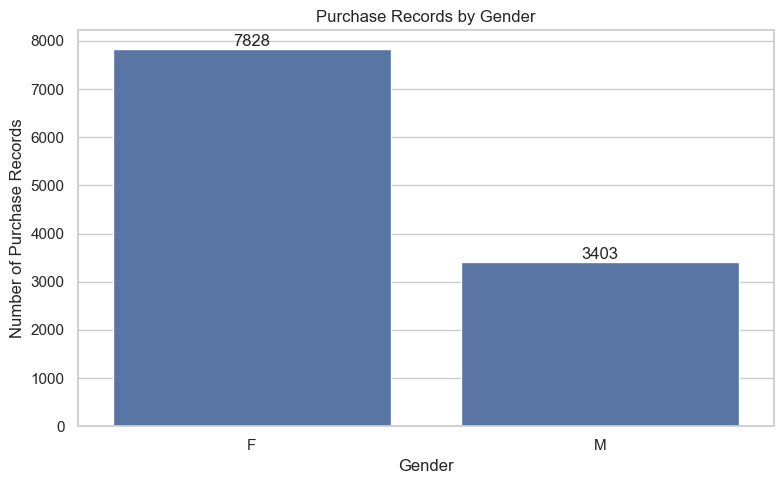

In [18]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_summary,
    x="Gender",
    y="Purchase_Records"
)

plt.title("Purchase Records by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Purchase Records")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

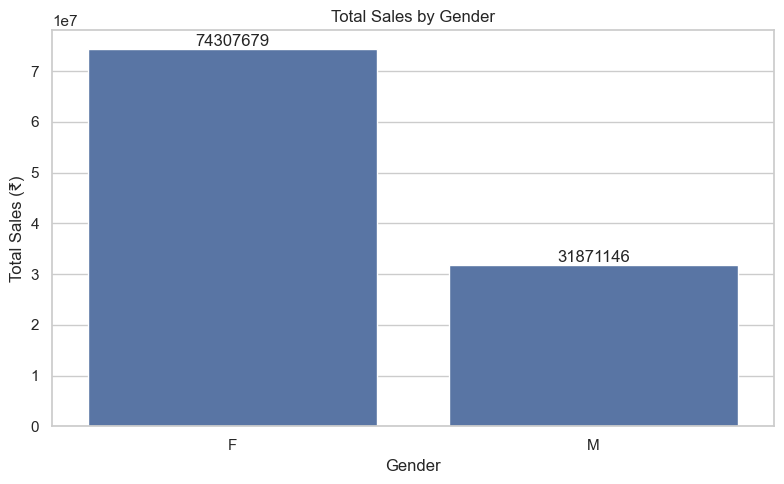

In [19]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_summary,
    x="Gender",
    y="Total_Sales"
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales (₹)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

In [20]:
# Identify the leading gender

top_gender = gender_summary.loc[
    gender_summary["Total_Sales"].idxmax()
]

print(
    f"Gender with the highest total sales: {top_gender['Gender']}"
)

print(
    f"Sales contribution: {top_gender['Sales_Share_%']:.2f}%"
)

print(
    f"Average purchase amount: ₹{top_gender['Average_Purchase']:.2f}"
)

Gender with the highest total sales: F
Sales contribution: 69.98%
Average purchase amount: ₹9492.55


In [21]:
# Create readable gender labels

gender_summary["Gender_Label"] = gender_summary["Gender"].map({
    "F": "Female",
    "M": "Male"
})

gender_summary

,Gender,Purchase_Records,Total_Sales,Average_Purchase,Record_Share_%,Sales_Share_%,Gender_Label
0,F,7828,74307679,9492.549693,69.699938,69.98352,Female
1,M,3403,31871146,9365.602703,30.300062,30.01648,Male


In [22]:
female_sales_share = gender_summary.loc[
    gender_summary["Gender"] == "F", "Sales_Share_%"
].iloc[0]

print(
    f"Female customers contributed {female_sales_share:.2f}% "
    "of total sales, making them the dominant gender segment."
)

Female customers contributed 69.98% of total sales, making them the dominant gender segment.


# Age Group Analysis

This section analyzes purchasing behavior across different age groups to identify the strongest customer segments by purchase volume and total sales.

In [23]:
age_summary = (
    df.groupby("Age Group")
      .agg(
          Purchase_Records=("Age Group", "size"),
          Total_Sales=("Amount", "sum"),
          Average_Purchase=("Amount", "mean")
      )
      .reset_index()
)

age_summary

,Age Group,Purchase_Records,Total_Sales,Average_Purchase
0,0-17,296,2699653,9120.449324
1,18-25,1878,17235530,9177.598509
2,26-35,4536,42581767,9387.514771
3,36-45,2282,22135135,9699.883874
4,46-50,983,9207844,9367.084435
5,51-55,829,8237909,9937.164053
6,55+,427,4080987,9557.346604


In [24]:
age_order = [
    "0-17",
    "18-25",
    "26-35",
    "36-45",
    "46-50",
    "51-55",
    "55+"
]

age_summary["Age Group"] = pd.Categorical(
    age_summary["Age Group"],
    categories=age_order,
    ordered=True
)

age_summary = age_summary.sort_values("Age Group")

age_summary

,Age Group,Purchase_Records,Total_Sales,Average_Purchase
0,0-17,296,2699653,9120.449324
1,18-25,1878,17235530,9177.598509
2,26-35,4536,42581767,9387.514771
3,36-45,2282,22135135,9699.883874
4,46-50,983,9207844,9367.084435
5,51-55,829,8237909,9937.164053
6,55+,427,4080987,9557.346604


In [25]:
age_summary["Sales_Share_%"] = (
    age_summary["Total_Sales"]
    / age_summary["Total_Sales"].sum()
    * 100
)

age_summary.round(2)

,Age Group,Purchase_Records,Total_Sales,Average_Purchase,Sales_Share_%
0,0-17,296,2699653,9120.45,2.54
1,18-25,1878,17235530,9177.60,16.23
2,26-35,4536,42581767,9387.51,40.10
3,36-45,2282,22135135,9699.88,20.85
4,46-50,983,9207844,9367.08,8.67
5,51-55,829,8237909,9937.16,7.76
6,55+,427,4080987,9557.35,3.84


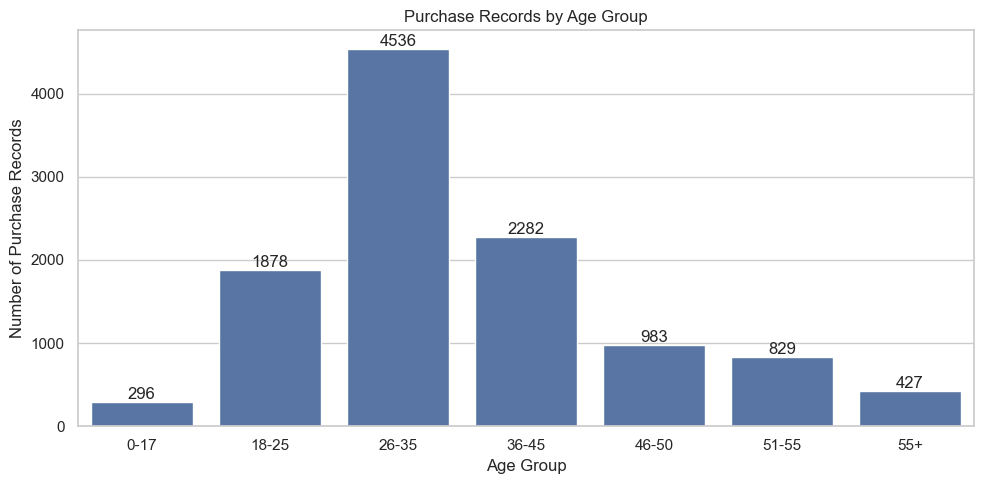

In [26]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=age_summary,
    x="Age Group",
    y="Purchase_Records"
)

plt.title("Purchase Records by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Purchase Records")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

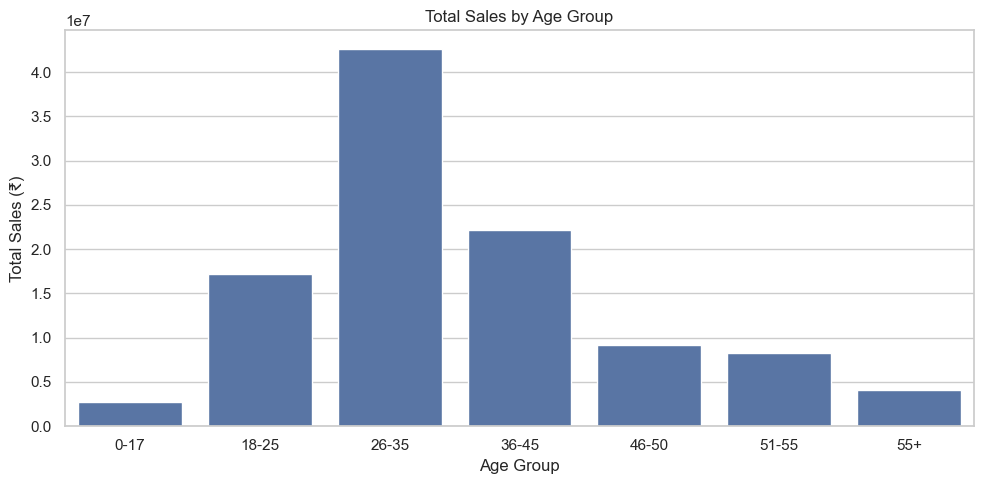

In [27]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=age_summary,
    x="Age Group",
    y="Total_Sales"
)

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales (₹)")

plt.tight_layout()
plt.show()

In [28]:
top_age_group = age_summary.loc[
    age_summary["Total_Sales"].idxmax()
]

print(
    f"Highest-revenue age group: {top_age_group['Age Group']}"
)

print(
    f"Sales contribution: {top_age_group['Sales_Share_%']:.2f}%"
)

print(
    f"Total sales: ₹{top_age_group['Total_Sales']:,}"
)

Highest-revenue age group: 26-35
Sales contribution: 40.10%
Total sales: ₹42,581,767


# Age Group and Gender Analysis

This analysis combines age group and gender to identify the customer segment contributing the highest sales.

In [29]:
age_gender_summary = (
    df.groupby(["Age Group", "Gender"])
      .agg(
          Purchase_Records=("Amount", "size"),
          Total_Sales=("Amount", "sum"),
          Average_Purchase=("Amount", "mean")
      )
      .reset_index()
)

age_gender_summary

,Age Group,Gender,Purchase_Records,Total_Sales,Average_Purchase
0,0-17,F,162,1441409,8897.586420
1,0-17,M,134,1258244,9389.880597
2,18-25,F,1305,11887003,9108.814559
3,18-25,M,573,5348527,9334.253054
4,26-35,F,3266,30945638,9475.088181
5,26-35,M,1270,11636129,9162.306299
6,36-45,F,1577,15500097,9828.850349
7,36-45,M,705,6635038,9411.401418
8,46-50,F,693,6743393,9730.725830
9,46-50,M,290,2464451,8498.106897


In [30]:
top_age_gender = age_gender_summary.loc[
    age_gender_summary["Total_Sales"].idxmax()
]

print(
    f"Top customer segment: "
    f"{top_age_gender['Age Group']} {top_age_gender['Gender']}"
)

print(
    f"Total sales: ₹{top_age_gender['Total_Sales']:,}"
)

print(
    f"Purchase records: {top_age_gender['Purchase_Records']:,}"
)

print(
    f"Average purchase: ₹{top_age_gender['Average_Purchase']:,.2f}"
)

Top customer segment: 26-35 F
Total sales: ₹30,945,638
Purchase records: 3,266
Average purchase: ₹9,475.09


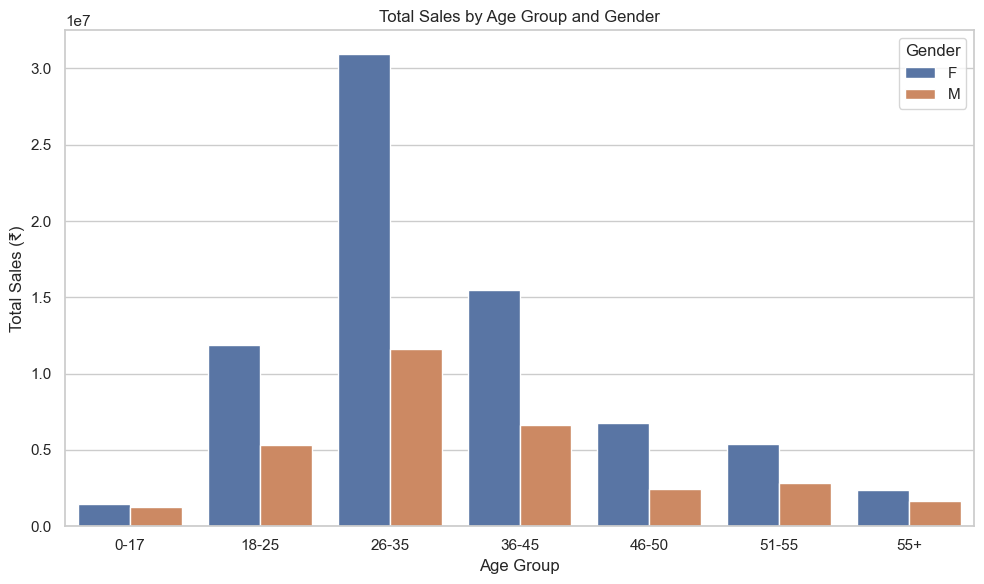

In [31]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_gender_summary,
    x="Age Group",
    y="Total_Sales",
    hue="Gender"
)

plt.title("Total Sales by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Total Sales (₹)")

plt.tight_layout()
plt.show()

# Geographic Analysis

## State-wise Sales Performance

This section analyzes order volume and total sales across states to identify the strongest geographic markets.

In [32]:
state_summary = (
    df.groupby("State")
      .agg(
          Total_Orders=("Orders", "sum"),
          Total_Sales=("Amount", "sum")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

state_summary

,State,Total_Orders,Total_Sales
14,Uttar Pradesh,4803,19346055
10,Maharashtra,3798,14404467
7,Karnataka,3240,13523540
2,Delhi,2740,11603818
9,Madhya Pradesh,2252,8101142
0,Andhra Pradesh,2051,8037146
5,Himachal Pradesh,1568,4963368
4,Haryana,1106,4217871
1,Bihar,1058,4014669
3,Gujarat,1063,3938159


In [33]:
top_states = state_summary.head(10)

top_states

,State,Total_Orders,Total_Sales
14,Uttar Pradesh,4803,19346055
10,Maharashtra,3798,14404467
7,Karnataka,3240,13523540
2,Delhi,2740,11603818
9,Madhya Pradesh,2252,8101142
0,Andhra Pradesh,2051,8037146
5,Himachal Pradesh,1568,4963368
4,Haryana,1106,4217871
1,Bihar,1058,4014669
3,Gujarat,1063,3938159


In [34]:
top_states = top_states.copy()

top_states["Sales_Share_%"] = (
    top_states["Total_Sales"]
    / state_summary["Total_Sales"].sum()
    * 100
)

top_states.round(2)

,State,Total_Orders,Total_Sales,Sales_Share_%
14,Uttar Pradesh,4803,19346055,18.22
10,Maharashtra,3798,14404467,13.57
7,Karnataka,3240,13523540,12.74
2,Delhi,2740,11603818,10.93
9,Madhya Pradesh,2252,8101142,7.63
0,Andhra Pradesh,2051,8037146,7.57
5,Himachal Pradesh,1568,4963368,4.67
4,Haryana,1106,4217871,3.97
1,Bihar,1058,4014669,3.78
3,Gujarat,1063,3938159,3.71


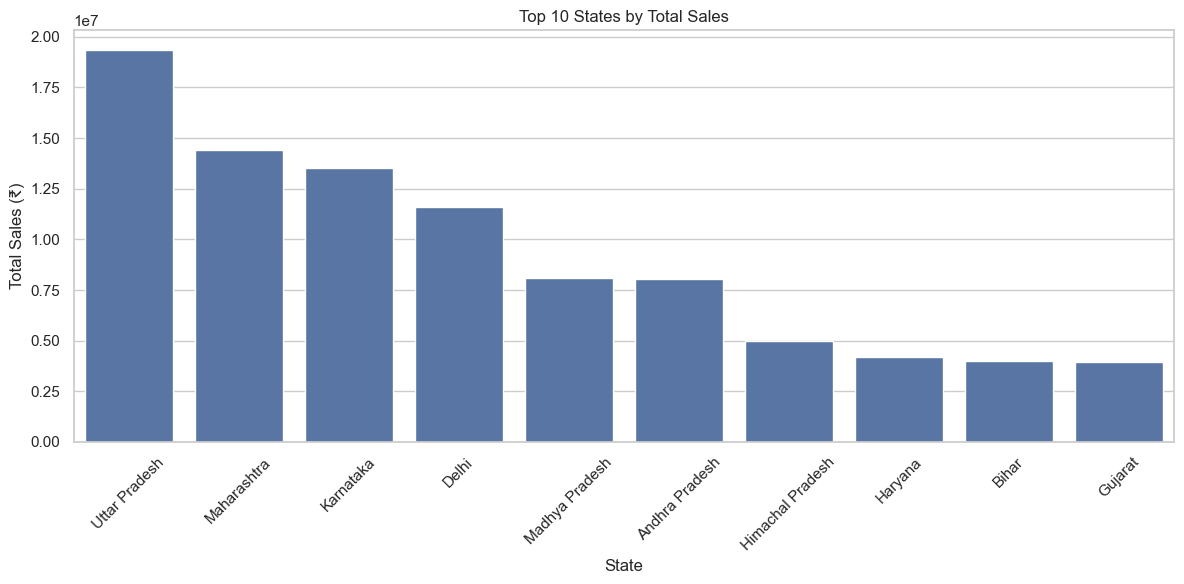

In [35]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_states,
    x="State",
    y="Total_Sales"
)

plt.title("Top 10 States by Total Sales")
plt.xlabel("State")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
top_state = state_summary.iloc[0]

print(f"Top state by sales: {top_state['State']}")
print(f"Total sales: ₹{top_state['Total_Sales']:,}")
print(f"Total orders: {top_state['Total_Orders']:,}")

Top state by sales: Uttar Pradesh
Total sales: ₹19,346,055
Total orders: 4,803


# Occupation Analysis

This section examines customer purchase behavior across occupations to identify the professional segments contributing the most sales.

In [37]:
occupation_summary = (
    df.groupby("Occupation")
      .agg(
          Purchase_Records=("Occupation", "size"),
          Total_Sales=("Amount", "sum"),
          Average_Purchase=("Amount", "mean")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

occupation_summary

,Occupation,Purchase_Records,Total_Sales,Average_Purchase
10,IT Sector,1581,14741862,9324.390892
8,Healthcare,1408,13034586,9257.518466
2,Aviation,1309,12599994,9625.663866
3,Banking,1137,10770610,9472.832014
7,Govt,854,8517212,9973.316159
9,Hospitality,700,6337633,9053.761429
12,Media,637,6295832,9883.566719
1,Automobile,565,5368596,9501.939823
4,Chemical,541,5297436,9791.933457
11,Lawyer,531,4981665,9381.666667


In [38]:
top_occupations = occupation_summary.head(5)

top_occupations

,Occupation,Purchase_Records,Total_Sales,Average_Purchase
10,IT Sector,1581,14741862,9324.390892
8,Healthcare,1408,13034586,9257.518466
2,Aviation,1309,12599994,9625.663866
3,Banking,1137,10770610,9472.832014
7,Govt,854,8517212,9973.316159


In [39]:
top_occupations = top_occupations.copy()

top_occupations["Sales_Share_%"] = (
    top_occupations["Total_Sales"]
    / occupation_summary["Total_Sales"].sum()
    * 100
)

top_occupations.round(2)

,Occupation,Purchase_Records,Total_Sales,Average_Purchase,Sales_Share_%
10,IT Sector,1581,14741862,9324.39,13.88
8,Healthcare,1408,13034586,9257.52,12.28
2,Aviation,1309,12599994,9625.66,11.87
3,Banking,1137,10770610,9472.83,10.14
7,Govt,854,8517212,9973.32,8.02


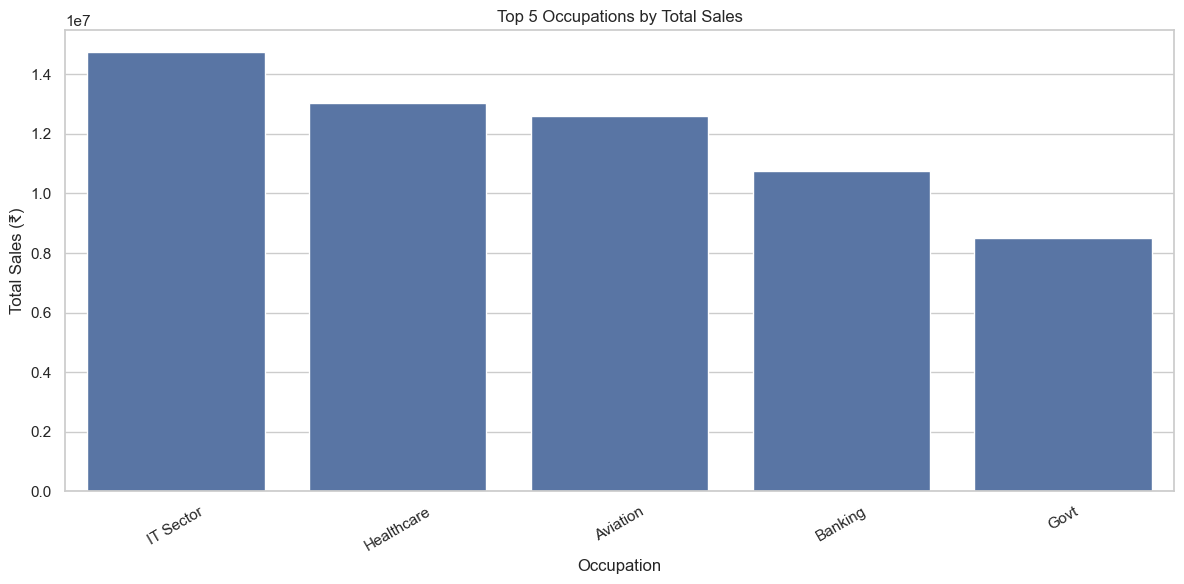

In [40]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_occupations,
    x="Occupation",
    y="Total_Sales"
)

plt.title("Top 5 Occupations by Total Sales")
plt.xlabel("Occupation")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [41]:
top_occupation = occupation_summary.iloc[0]

print(f"Top occupation by sales: {top_occupation['Occupation']}")
print(f"Total sales: ₹{top_occupation['Total_Sales']:,}")
print(f"Purchase records: {top_occupation['Purchase_Records']:,}")
print(f"Average purchase: ₹{top_occupation['Average_Purchase']:,.2f}")

Top occupation by sales: IT Sector
Total sales: ₹14,741,862
Purchase records: 1,581
Average purchase: ₹9,324.39


# Product Category Analysis

This section analyzes product categories to identify the products generating the highest purchase volume and revenue.

In [42]:
category_summary = (
    df.groupby("Product_Category")
      .agg(
          Purchase_Records=("Product_Category", "size"),
          Total_Sales=("Amount", "sum"),
          Average_Purchase=("Amount", "mean")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

category_summary

,Product_Category,Purchase_Records,Total_Sales,Average_Purchase
6,Food,2490,33933883,13628.065462
3,Clothing & Apparel,2653,16484472,6213.521297
5,Electronics & Gadgets,2082,15607657,7496.473103
7,Footwear & Shoes,1059,15575209,14707.468366
8,Furniture,352,5440051,15454.690341
9,Games & Toys,386,4331694,11222.005181
14,Sports Products,356,3635933,10213.294944
1,Beauty,422,1959484,4643.327014
0,Auto,96,1935041,20156.677083
15,Stationery,112,1676051,14964.741071


In [43]:
top_categories = category_summary.head(5)

top_categories

,Product_Category,Purchase_Records,Total_Sales,Average_Purchase
6,Food,2490,33933883,13628.065462
3,Clothing & Apparel,2653,16484472,6213.521297
5,Electronics & Gadgets,2082,15607657,7496.473103
7,Footwear & Shoes,1059,15575209,14707.468366
8,Furniture,352,5440051,15454.690341


In [44]:
top_categories = top_categories.copy()

top_categories["Sales_Share_%"] = (
    top_categories["Total_Sales"]
    / category_summary["Total_Sales"].sum()
    * 100
)

top_categories.round(2)

,Product_Category,Purchase_Records,Total_Sales,Average_Purchase,Sales_Share_%
6,Food,2490,33933883,13628.07,31.96
3,Clothing & Apparel,2653,16484472,6213.52,15.53
5,Electronics & Gadgets,2082,15607657,7496.47,14.70
7,Footwear & Shoes,1059,15575209,14707.47,14.67
8,Furniture,352,5440051,15454.69,5.12


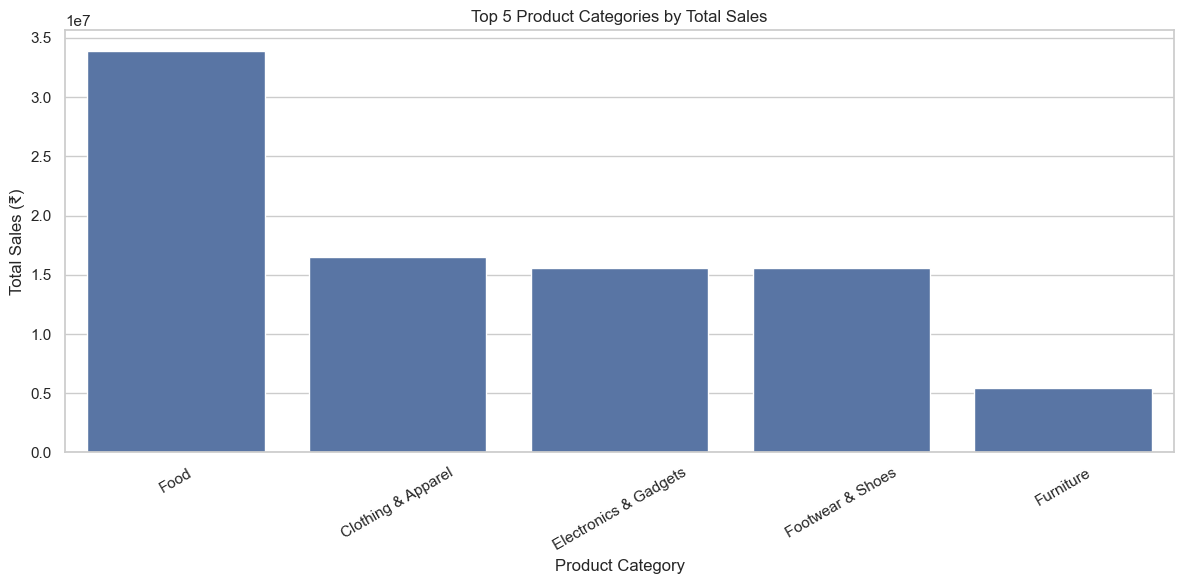

In [45]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_categories,
    x="Product_Category",
    y="Total_Sales"
)

plt.title("Top 5 Product Categories by Total Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [46]:
top_category = category_summary.iloc[0]

print(f"Top product category: {top_category['Product_Category']}")
print(f"Total sales: ₹{top_category['Total_Sales']:,}")
print(f"Purchase records: {top_category['Purchase_Records']:,}")
print(f"Average purchase: ₹{top_category['Average_Purchase']:,.2f}")

Top product category: Food
Total sales: ₹33,933,883
Purchase records: 2,490
Average purchase: ₹13,628.07


# Product Category and Gender Analysis

This analysis compares purchasing behavior across product categories and gender to identify the strongest customer segments for each category.

In [47]:
category_gender_summary = (
    df.groupby(["Product_Category", "Gender"])
      .agg(
          Purchase_Records=("Amount", "size"),
          Total_Sales=("Amount", "sum"),
          Average_Purchase=("Amount", "mean")
      )
      .reset_index()
)

category_gender_summary

,Product_Category,Gender,Purchase_Records,Total_Sales,Average_Purchase
0,Auto,F,64,1285791,20090.484375
1,Auto,M,32,649250,20289.062500
2,Beauty,F,325,1524257,4690.021538
3,Beauty,M,97,435227,4486.876289
4,Books,F,39,404215,10364.487179
5,Books,M,64,657263,10269.734375
6,Clothing & Apparel,F,1854,11479103,6191.533441
7,Clothing & Apparel,M,799,5005369,6264.541927
8,Decor,F,79,596994,7556.886076
9,Decor,M,17,133366,7845.058824


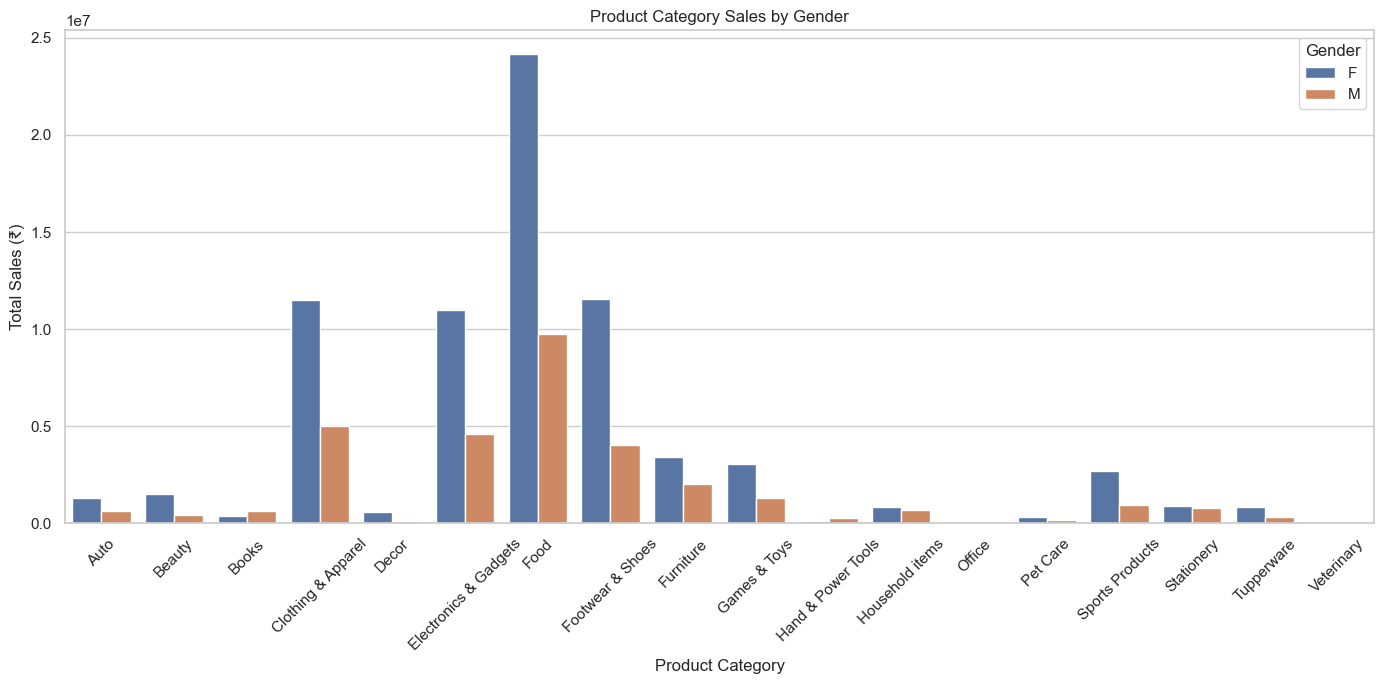

In [48]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=category_gender_summary,
    x="Product_Category",
    y="Total_Sales",
    hue="Gender"
)

plt.title("Product Category Sales by Gender")
plt.xlabel("Product Category")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
top_category_gender = category_gender_summary.loc[
    category_gender_summary["Total_Sales"].idxmax()
]

print(
    f"Top category-gender segment: "
    f"{top_category_gender['Product_Category']} - "
    f"{top_category_gender['Gender']}"
)

print(
    f"Total sales: ₹{top_category_gender['Total_Sales']:,}"
)

print(
    f"Purchase records: {top_category_gender['Purchase_Records']:,}"
)

print(
    f"Average purchase: ₹{top_category_gender['Average_Purchase']:,.2f}"
)

Top category-gender segment: Food - F
Total sales: ₹24,176,102
Purchase records: 1,771
Average purchase: ₹13,651.10


# Executive Summary

## Key Business Insights

The analysis identifies the major customer segments, geographic markets, occupations, and product categories contributing to overall sales.

### Key Findings

- Customers aged **26–35** generate the highest total sales.
- **Female customers aged 26–35** represent the largest age-gender sales segment.
- **Uttar Pradesh** generates the highest state-level sales.
- Customers working in the **IT Sector** contribute the highest occupation-level sales.
- **Food** is the highest-revenue product category.
- **Food purchased by female customers** represents the largest product-category and gender segment.

## Business Recommendations

- Focus marketing campaigns on the **26–35 customer segment**.
- Strengthen customer acquisition and retention strategies in high-revenue states.
- Explore targeted campaigns for high-value occupational segments.
- Maintain strong availability of high-performing product categories.
- Use customer segmentation to create more personalized promotions.

In [50]:
total_sales = df["Amount"].sum()
total_orders = df["Orders"].sum()
total_records = len(df)
average_purchase = df["Amount"].mean()
unique_customers = df["User_ID"].nunique()
unique_products = df["Product_ID"].nunique()

print(f"Total Sales: ₹{total_sales:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Purchase Records: {total_records:,}")
print(f"Average Purchase Amount: ₹{average_purchase:,.2f}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Unique Products: {unique_products:,}")

Total Sales: ₹106,178,825
Total Orders: 27,955
Purchase Records: 11,231
Average Purchase Amount: ₹9,454.08
Unique Customers: 3,752
Unique Products: 2,350


In [51]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Orders",
        "Purchase Records",
        "Average Purchase",
        "Unique Customers",
        "Unique Products"
    ],
    "Value": [
        f"₹{total_sales:,}",
        f"{total_orders:,}",
        f"{total_records:,}",
        f"₹{average_purchase:,.2f}",
        f"{unique_customers:,}",
        f"{unique_products:,}"
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,"₹106,178,825"
1,Total Orders,"27,955"
2,Purchase Records,"11,231"
3,Average Purchase,"₹9,454.08"
4,Unique Customers,"3,752"
5,Unique Products,"2,350"


# Conclusion

## Summary of Findings

The analysis of Diwali sales data provides insights into customer demographics, geographic markets, occupations, and product preferences.

The dataset contains 11,231 purchase records after data cleaning, representing 3,752 unique customers and 2,350 unique products.

The analysis shows that the 26–35 age group contributes the highest sales, with female customers forming the largest age-gender sales segment. Uttar Pradesh records the highest state-level sales, while customers working in the IT sector contribute the highest occupation-level sales.

Among product categories, Food generates the highest revenue and accounts for 31.96% of total sales. Female customers purchasing Food also represent the largest category-gender sales segment.

These findings can help businesses improve customer segmentation, regional marketing, product availability, and targeted promotional strategies.

## Key Business Insights

| Area | Key Insight |
|---|---|
| Age Group | 26–35 generates the highest sales |
| Gender | Female customers contribute the largest sales |
| Age + Gender | 26–35 Female is the largest segment |
| State | Uttar Pradesh generates the highest sales |
| Occupation | IT Sector generates the highest sales |
| Product Category | Food generates the highest sales |
| Category + Gender | Food – Female is the largest segment |
| Total Sales | ₹10.62 Crore |